In [1]:
import matplotlib
import seaborn
import plotly

In [2]:
#перевірити версії
print('matplptlib version:', matplotlib.__version__)
print('seaborn version:', seaborn.__version__)
print('plotly version:', plotly.__version__)

matplptlib version: 3.10.0
seaborn version: 0.13.2
plotly version: 5.24.1


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
%matplotlib inline

In [5]:
sales_data = pd.read_csv('ecom_cosmetics_sales_data.csv', index_col=0)
sales_data.head()

,visitors,sales,conversion,avg_order_value,income
2024-01-01,2167,75,0.032994,89.753640,6731.523007
2024-01-02,1983,52,0.036120,91.450902,4755.446886
2024-01-03,2226,86,0.035063,70.794979,6088.368237
2024-01-04,2495,54,0.035488,100.061359,5403.313391
2024-01-05,1976,82,0.031135,94.492687,7748.400304


In [6]:
type(sales_data.index[0])

str

In [7]:
# для перетворення індексу об'єкта DataFrame (або Series) у формат дати та часу (DatetimeIndex) 
sales_data.index = pd.to_datetime(sales_data.index)

In [8]:
type(sales_data.index[0])

pandas._libs.tslibs.timestamps.Timestamp

## Лінійний графік

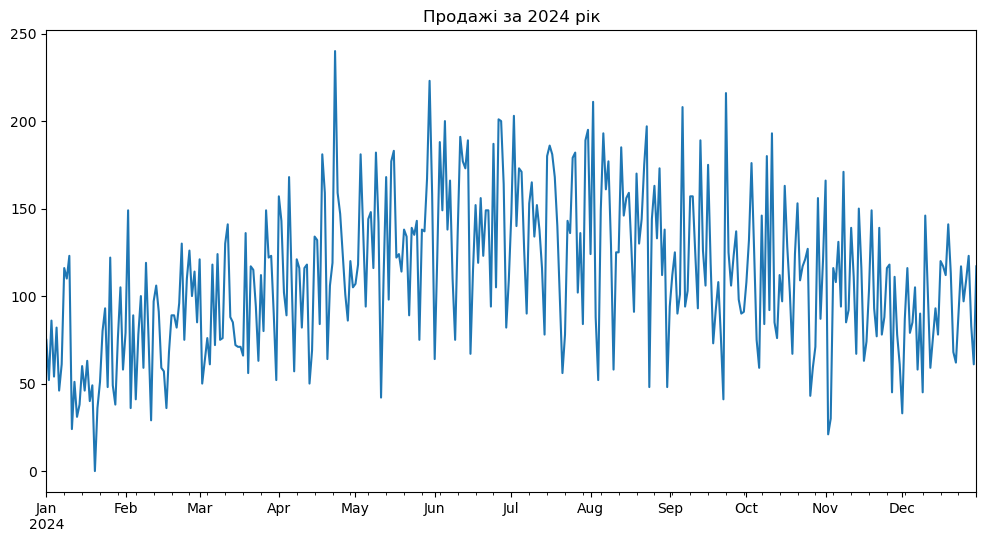

In [9]:
sales_data['sales'].plot(
    figsize= (12,6), title= 'Продажі за 2024 рік'
    )
plt.show()

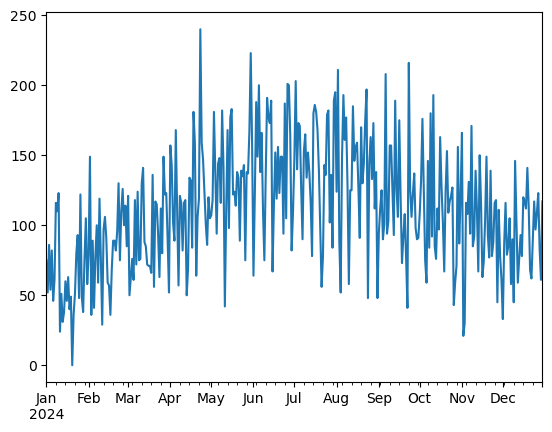

In [10]:
# викликати графік без налаштувань(за замовчуванням)
sales_data['sales'].plot()
plt.show()

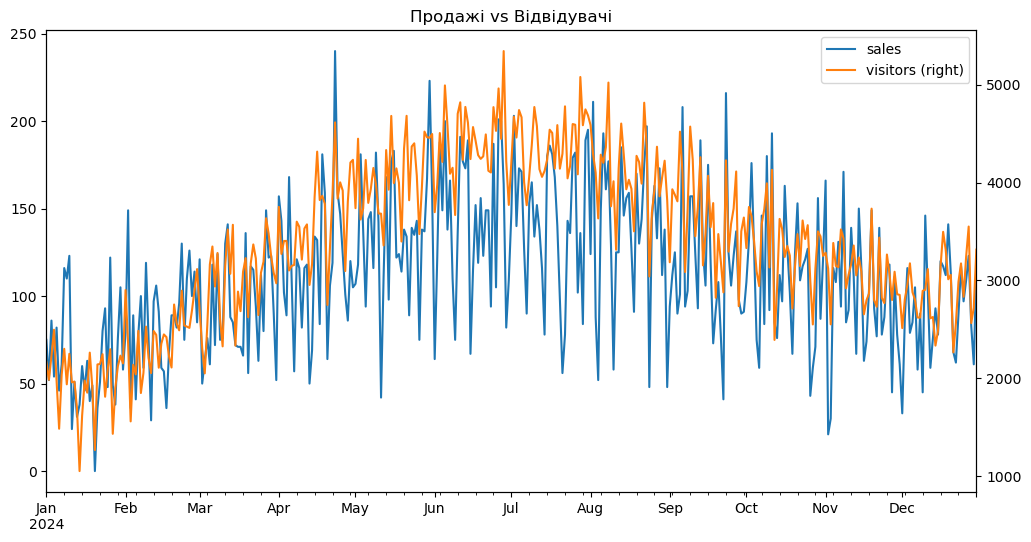

In [11]:
# Кілька серій одразу
sales_data[['sales', 'visitors']].plot(
    figsize=(12,6),             # розмір графіка: ширина 12 дюймів, висота 6
    secondary_y='visitors',
    title='Продажі vs Відвідувачі')
plt.show()

In [12]:
# Місячні продажі
monthly_sales = sales_data['sales'].resample('ME').sum()

In [13]:
monthly_sales

2024-01-31    1963
2024-02-29    2465
2024-03-31    2869
2024-04-30    3559
2024-05-31    4185
2024-06-30    4250
2024-07-31    4420
2024-08-31    4231
2024-09-30    3550
2024-10-31    3490
2024-11-30    2991
2024-12-31    2781
Freq: ME, Name: sales, dtype: int64

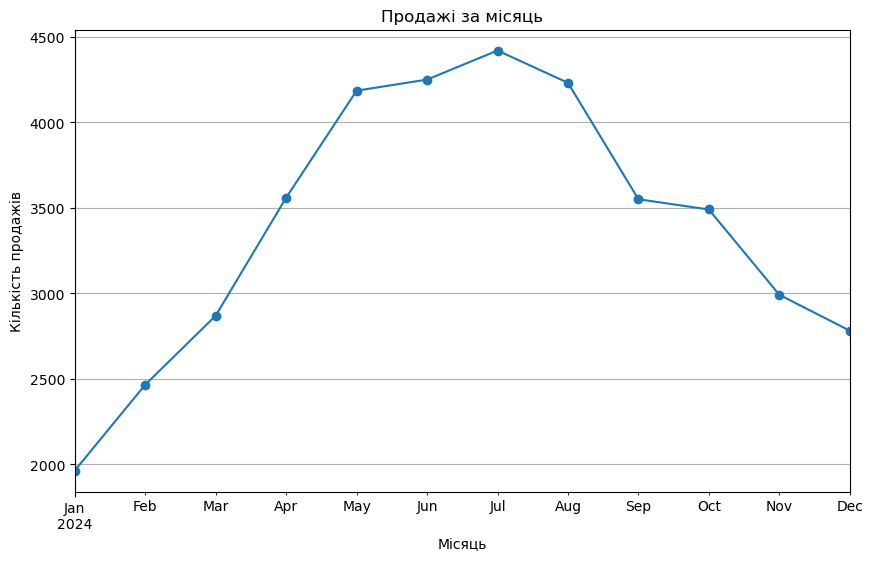

In [14]:
monthly_sales.plot(
    kind='line',                 # тип графіка: лінійний графік
    marker='o',                  # маркери у вигляді кружечків на кожній точці
    figsize=(10, 6),             # розміри графіка: ширина 10 дюймів, висота 6
    title='Продажі за місяць',   # заголовок графіка
    xlabel='Місяць',             # підпис осі X
    ylabel='Кількість продажів', # підпис осі Y
    grid=True                    # вмикає сітку на графіку
)
plt.show()

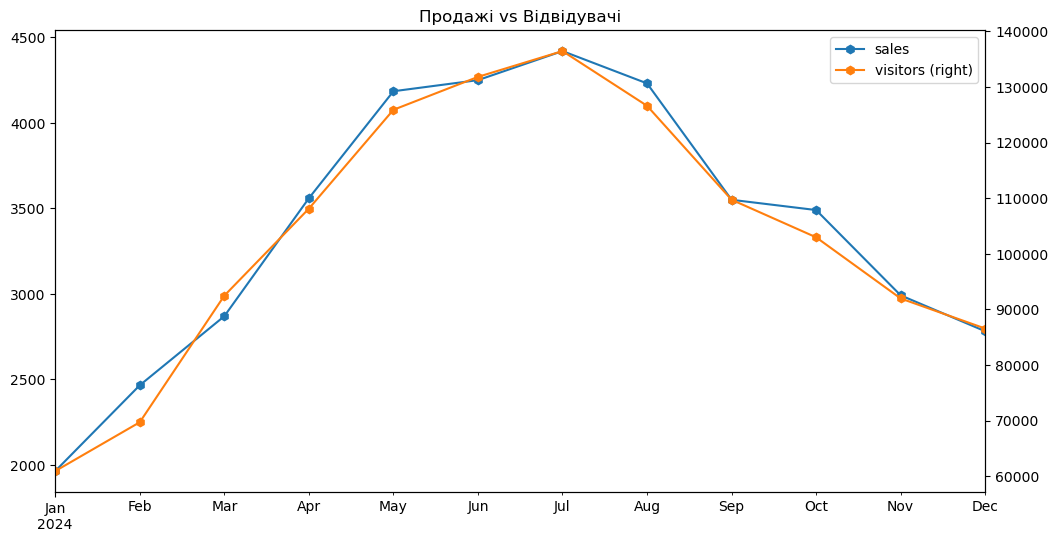

In [15]:
# Кілька серій на одному полотні
monthly_sales= sales_data[['sales', 'visitors']].resample('ME').sum()
monthly_sales.plot(
    figsize=(12,6),
    marker='h',
    secondary_y='visitors',
    title='Продажі vs Відвідувачі')
plt.show()
    

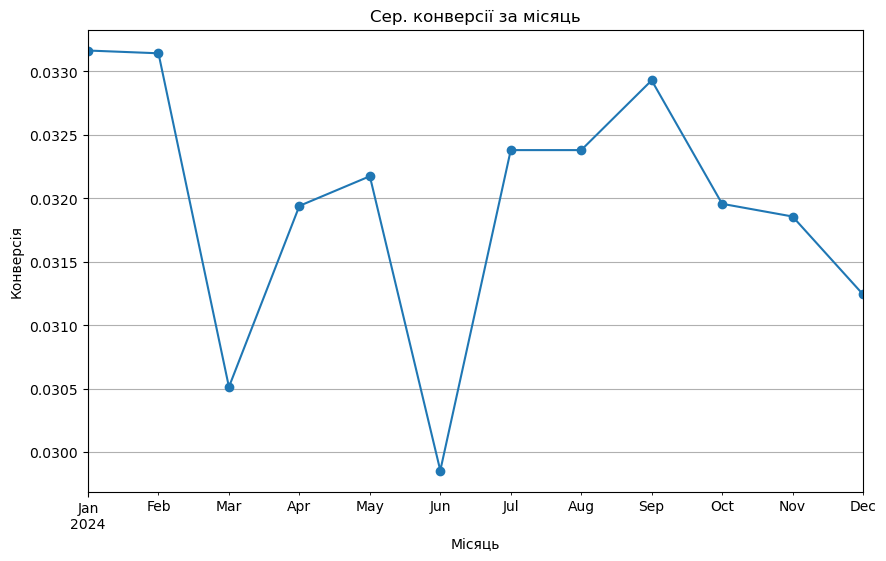

In [15]:
sales_data['conversion'].resample('ME').mean().plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
    title='Сер. конверсії за місяць',
    xlabel='Місяць',
    ylabel='Конверсія',
    grid=True)
plt.show()

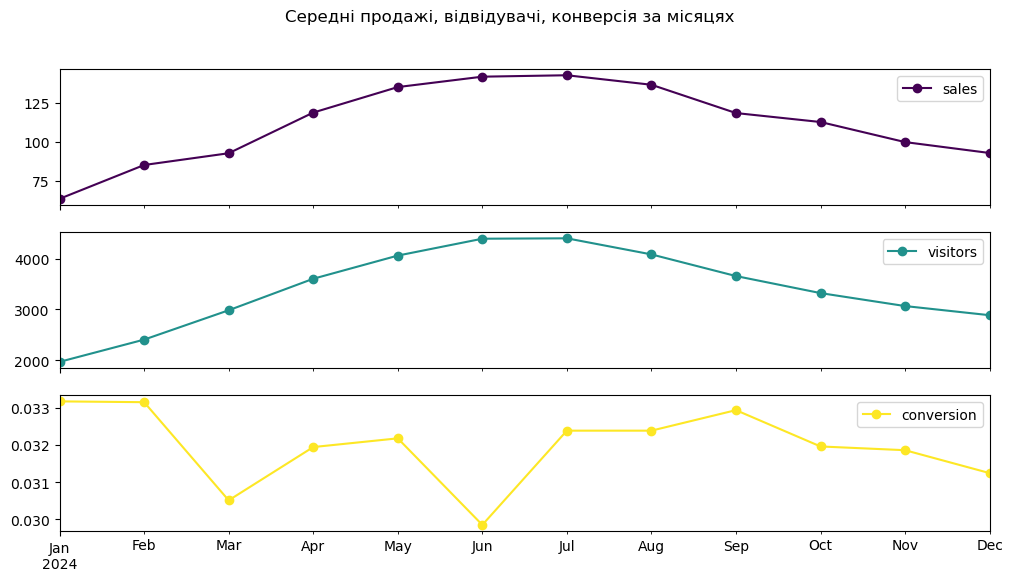

In [17]:
# Кілька серій одразу
monthly_data= sales_data[['sales', 'visitors', 'conversion']].resample('ME').mean()
monthly_data.plot(
    figsize=(12,6),
    marker='o',
    subplots= True,       # кожна змінна на окремому графіку
    colormap='viridis',   # автоматичне забарвлення графіків
    title='Середні продажі, відвідувачі, конверсія за місяцях')
plt.show()
    

## Стовпчаста діаграма

In [19]:
sales_data.nlargest(10, 'income')    # повертає 10 рядків із найбільшими значеннями в колонці income

,visitors,sales,conversion,avg_order_value,income
2024-06-05,4993,200,0.037717,157.307488,31461.497549
2024-08-02,4288,211,0.040719,146.983643,31013.548600
2024-07-15,4233,180,0.045377,172.248134,31004.664134
2024-07-02,4673,203,0.036856,151.308902,30715.707089
2024-05-30,4458,223,0.038777,135.775714,30277.984266
2024-06-24,4771,187,0.039178,160.850616,30079.065198
2024-06-11,4820,191,0.035240,153.810673,29377.838613
2024-06-14,4613,189,0.038193,155.409806,29372.453397
2024-08-23,4351,197,0.038785,148.984709,29349.987698
2024-06-27,4447,200,0.042208,146.633621,29326.724196


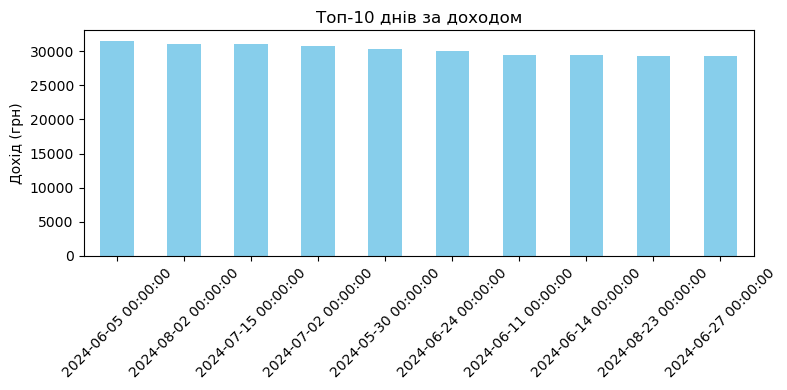

In [23]:
# ТОП-10 днів за доходом
top_days = sales_data.nlargest(10, 'income')['income']  # вибирає 10 рядків із найбільшим доходом i ['income']→ залишає тільки стовпець income
top_days.plot.bar(       # могли написати альтернативу kind='bar'
    figsize = (8,4),
    color = 'skyblue',
    title = 'Топ-10 днів за доходом',
    ylabel = 'Дохід (грн)',
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()    
    
    
    

In [24]:
top_days.index

DatetimeIndex(['2024-06-05', '2024-08-02', '2024-07-15', '2024-07-02',
               '2024-05-30', '2024-06-24', '2024-06-11', '2024-06-14',
               '2024-08-23', '2024-06-27'],
              dtype='datetime64[ns]', freq=None)

In [25]:
[date.strftime('%d %b %Y') for date in top_days.index]

['05 Jun 2024',
 '02 Aug 2024',
 '15 Jul 2024',
 '02 Jul 2024',
 '30 May 2024',
 '24 Jun 2024',
 '11 Jun 2024',
 '14 Jun 2024',
 '23 Aug 2024',
 '27 Jun 2024']

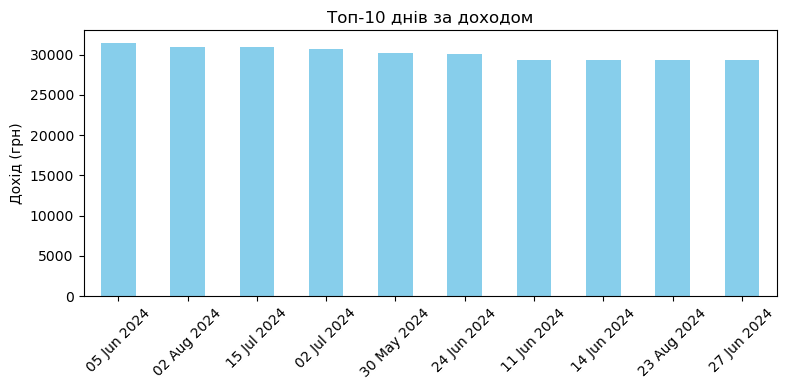

In [29]:
# Формуємо дати для кращого відображення
ax = top_days.plot.bar(      # зберігаємо графік у змінну ax
    figsize = (8,4),
    color = 'skyblue',
    title = 'Топ-10 днів за доходом',
    ylabel = 'Дохід (грн)'
)

# Формуємо підписи осі Х- тільки дата та скорочена назва місяця
labels = [date.strftime('%d %b %Y') for date in top_days.index]
ax.set_xticklabels(labels)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

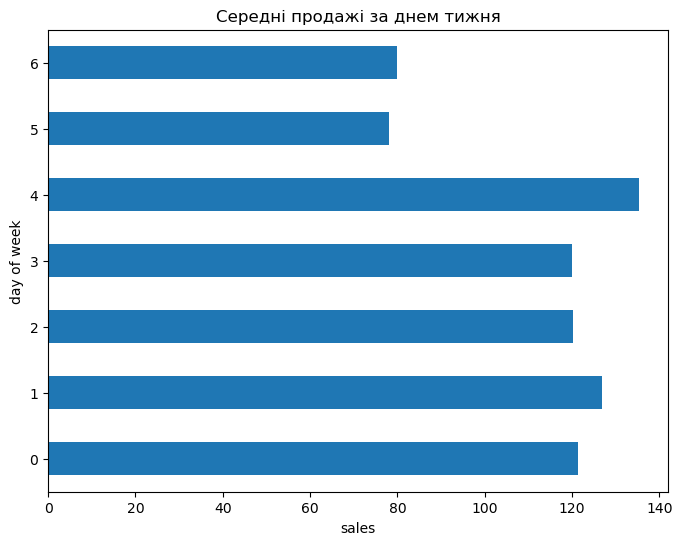

In [31]:
# Горизонтальна версія
sales_data.groupby(sales_data.index.weekday)['sales'].mean().plot.barh(
    figsize = (8, 6),
    title = 'Середні продажі за днем тижня',
    xlabel = 'sales',
    ylabel = 'day of week',
)
plt.show()
    

In [32]:
avg_sales_by_day = sales_data.groupby(sales_data.index.weekday)['sales'].mean()

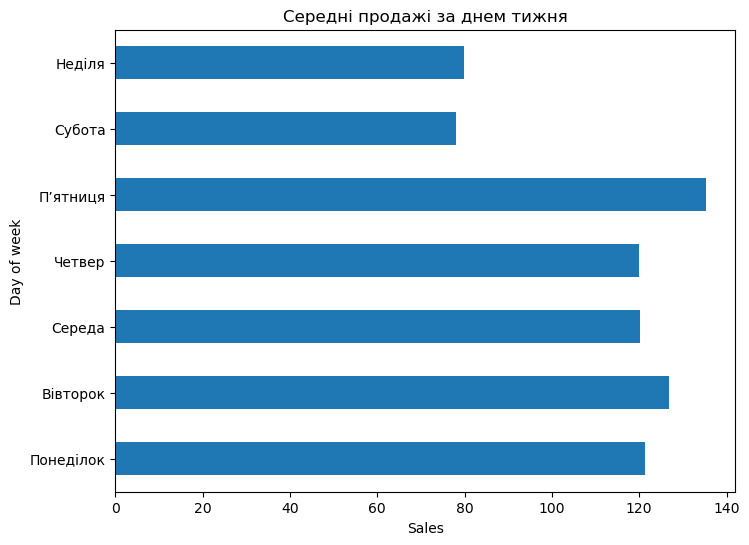

In [40]:
ax = avg_sales_by_day.plot.barh(
    figsize = (8, 6),
    title = 'Середні продажі за днем тижня',
    xlabel = 'Sales',
    ylabel = 'Day of week',
)

# Налаштування підписів днів тижня
ax.set_yticklabels(['Понеділок', 'Вівторок', 'Середа', 'Четвер', 'Пʼятниця', 'Субота', 'Неділя'])
plt.show()